In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from mlxtend.plotting import plot_confusion_matrix
from sklearn import tree
import math
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('/content/diabetes_binary_health_indicators_BRFSS2015.csv')

In [ ]:
df.shape

(46783, 22)

In [ ]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [ ]:
df.tail()


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
46778,0.0,0.0,0.0,1.0,21.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,2.0,0.0,1.0,8.0,6.0,8.0
46779,0.0,0.0,0.0,0.0,31.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,10.0,3.0,2.0
46780,0.0,0.0,0.0,1.0,21.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.0,0.0,0.0,0.0,0.0,2.0,4.0,3.0
46781,0.0,0.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,6.0,6.0,8.0
46782,0.0,1.0,1.0,1.0,31.0,1.0,0.0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.isnull().sum()


,0
Diabetes_binary,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,1
Fruits,1


In [ ]:
df.dropna(inplace = True)


In [ ]:
duplicate = df[df.duplicated()]
print("Duplicate Rows : ",len(duplicate))
duplicate

Duplicate Rows :  1983


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
1242,1.0,1.0,1.0,1.0,27.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,0.0,30.0,1.0,0.0,10.0,4.0,5.0
1563,0.0,0.0,0.0,1.0,21.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
2700,0.0,0.0,0.0,1.0,32.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,5.0,6.0,8.0
3160,0.0,0.0,0.0,1.0,21.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
3332,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,9.0,6.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46749,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,10.0,4.0,6.0
46762,0.0,0.0,0.0,1.0,20.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
46763,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,5.0,8.0
46776,0.0,0.0,0.0,1.0,21.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,6.0,6.0,8.0


In [ ]:
df.drop_duplicates(inplace = True)


In [ ]:
df.shape

(44799, 22)

In [ ]:
duplicate = df[df.duplicated()]
print("Duplicate Rows : ", len(duplicate))

Duplicate Rows :  0


In [ ]:
df['Diabetes_binary'].value_counts()


,count
Diabetes_binary,
0.0,38340
1.0,6459


<Axes: title={'center': 'Label Distribution'}, xlabel='Diabetes_binary'>

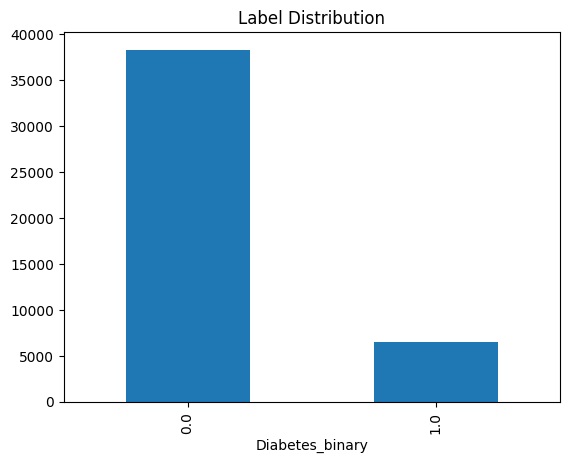

In [ ]:
df['Diabetes_binary'].value_counts().plot(kind = 'bar', title = 'Label Distribution')


<Axes: title={'center': 'Label Distribution after Oversampling'}, xlabel='Diabetes_binary'>

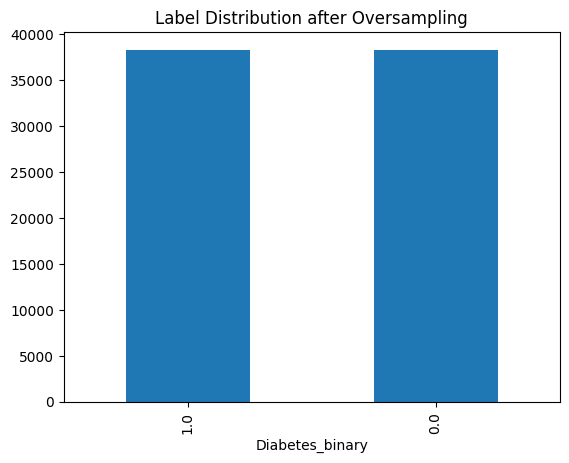

In [ ]:
class_0 = df[df['Diabetes_binary'] == 0]
class_1 = df[df['Diabetes_binary'] == 1]

class_1_over = class_1.sample(len(class_0), replace=True)

df_new = pd.concat([class_1_over, class_0], axis=0)
df_new['Diabetes_binary'].value_counts().plot(kind='bar', title='Label Distribution after Oversampling')

In [ ]:
X = df_new.drop('Diabetes_binary', axis = 1) # features
y = df_new[['Diabetes_binary']] # labels

# splitting the features and labels into train and test with test size = 20% and train size = 80%
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=10)

# Fitting machine learning models¶


In [ ]:
model_1 = RandomForestClassifier(n_estimators = 300, criterion = 'entropy',
                             min_samples_split=10, random_state=0)

# fitting the model on the train data
model_1.fit(X_train, y_train)

# predicting values on test data
predictions = model_1.predict(X_test)

In [ ]:
pred_df = pd.DataFrame()
pred_df['True values'] = y_test
pred_df['Predicted values'] = predictions
pred_df

,True values,Predicted values
14204,1.0,1.0
29568,1.0,1.0
5959,1.0,1.0
44244,1.0,1.0
4813,0.0,1.0
...,...,...
37286,1.0,1.0
3183,1.0,1.0
43801,1.0,1.0
14138,1.0,1.0


In [ ]:
accuracies = {}
accuracy_1 = accuracy_score(y_test, predictions)
accuracies['Random Forest Classifier'] = accuracy_1

# calculating the classification report
classificationreport = classification_report(y_test, predictions)

# calculating the mse
mse = mean_squared_error(y_test, predictions)

# calculating the rmse
rmse = math.sqrt(mse)
print('\nAccuracy score of Random Forest Classifier : ' + str(round(accuracy_1*100, 2)))
print("\n"+"*"*50)
print('\nClassification_report : ')
print(classificationreport)
print("\n"+"*"*50)
print('\nMean squared error : '+ str(mse))
print("\n"+"*"*50)
print('\nRoot mean squared error : '+ str(rmse))


Accuracy score of Random Forest Classifier : 91.86

**************************************************

Classification_report : 
              precision    recall  f1-score   support

         0.0       0.96      0.87      0.91      7673
         1.0       0.88      0.97      0.92      7663

    accuracy                           0.92     15336
   macro avg       0.92      0.92      0.92     15336
weighted avg       0.92      0.92      0.92     15336


**************************************************

Mean squared error : 0.08144235785080856

**************************************************

Root mean squared error : 0.28538107479440283


In [ ]:
!pip install gradio


In [ ]:
import joblib

joblib.dump(model_1, "rf_model.pkl")


['rf_model.pkl']

In [ ]:
import gradio as gr
import numpy as np
import joblib

# Load trained model
model = joblib.load("rf_model.pkl")

def predict_diabetes(
    HighBP, HighChol, CholCheck, BMI, Smoker, Stroke, HeartDiseaseorAttack,
    PhysActivity, Fruits, Veggies, HvyAlcoholConsump, AnyHealthcare, NoDocbcCost,
    GenHlth, MentHlth, PhysHlth, DiffWalk, Sex, Age, Education, Income,
    threshold
):
    input_data = np.array([[HighBP, HighChol, CholCheck, BMI, Smoker, Stroke, HeartDiseaseorAttack,
                            PhysActivity, Fruits, Veggies, HvyAlcoholConsump, AnyHealthcare, NoDocbcCost,
                            GenHlth, MentHlth, PhysHlth, DiffWalk, Sex, Age, Education, Income]])
    prob = model.predict_proba(input_data)[0][1]
    pred = "Diabetic" if prob > threshold else "Non-Diabetic"
    color = "🟥" if pred=="Diabetic" else "🟩"
    return f"{color} {pred}", f"{prob:.2f}"

custom_css = """
.small-btn {width:120px; height:35px; font-size:14px; margin:5px;}
"""

with gr.Blocks(css=custom_css) as demo:
    gr.Markdown("## Diabetes Prediction Model\nEnter personal data to predict diabetes probability")

    with gr.Row():
        with gr.Column(scale=1, min_width=200):
            HighBP = gr.Slider(0,1, step=1, label="HighBP", info="High Blood Pressure")
            HighChol = gr.Slider(0,1, step=1, label="HighChol", info="High Cholesterol")
            CholCheck = gr.Slider(0,1, step=1, label="CholCheck", info="Cholesterol check in last 5 years")
            BMI = gr.Number(label="BMI", info="Body Mass Index")
            Smoker = gr.Slider(0,1, step=1, label="Smoker", info="Smoker")
            Stroke = gr.Slider(0,1, step=1, label="Stroke", info="History of Stroke")
            HeartDiseaseorAttack = gr.Slider(0,1, step=1, label="HeartDisease", info="Heart Disease or Attack")
        with gr.Column(scale=1, min_width=200):
            PhysActivity = gr.Slider(0,1, step=1, label="PhysActivity", info="Physically active")
            Fruits = gr.Slider(0,1, step=1, label="Fruits", info="Consumes fruits")
            Veggies = gr.Slider(0,1, step=1, label="Veggies", info="Consumes vegetables")
            HvyAlcoholConsump = gr.Slider(0,1, step=1, label="HvyAlcohol", info="Heavy alcohol consumption")
            AnyHealthcare = gr.Slider(0,1, step=1, label="AnyHealthcare", info="Has healthcare access")
            NoDocbcCost = gr.Slider(0,1, step=1, label="NoDocbcCost", info="Did not see doctor due to cost")
            GenHlth = gr.Slider(1,5, step=1, label="GenHlth", info="General health (1-best, 5-worst)")
        with gr.Column(scale=1, min_width=200):
            MentHlth = gr.Slider(0,30, step=1, label="MentHlth", info="Days of poor mental health")
            PhysHlth = gr.Slider(0,30, step=1, label="PhysHlth", info="Days of poor physical health")
            DiffWalk = gr.Slider(0,1, step=1, label="DiffWalk", info="Difficulty walking")
            Sex = gr.Slider(0,1, step=1, label="Sex", info="Gender (0=Female,1=Male)")
            Age = gr.Slider(18,120, step=1, label="Age", info="Age in years")
            Education = gr.Slider(1,6, step=1, label="Education", info="Education level")
            Income = gr.Slider(1,8, step=1, label="Income", info="Income level")
            threshold = gr.Slider(0,1, step=0.01, value=0.5, label="Threshold", info="Prediction threshold")

    # Buttons row
    with gr.Row():
        btn_predict = gr.Button("Predict", elem_classes="small-btn")
        btn_reset = gr.Button("Reset", elem_classes="small-btn")

    # Output
    output_pred = gr.Label(label="Prediction")
    output_prob = gr.Label(label="Probability")

    btn_predict.click(
        predict_diabetes,
        inputs=[HighBP, HighChol, CholCheck, BMI, Smoker, Stroke, HeartDiseaseorAttack,
                PhysActivity, Fruits, Veggies, HvyAlcoholConsump, AnyHealthcare, NoDocbcCost,
                GenHlth, MentHlth, PhysHlth, DiffWalk, Sex, Age, Education, Income, threshold],
        outputs=[output_pred, output_prob]
    )

    # Reset button functionality
    def reset_all():
        return [0]*7 + [0]*6 + [1]*1 + [0]*2 + [18,1,1,1,0.5]  # default values
    btn_reset.click(reset_all, inputs=[], outputs=[HighBP, HighChol, CholCheck, BMI, Smoker, Stroke, HeartDiseaseorAttack,
                                                    PhysActivity, Fruits, Veggies, HvyAlcoholConsump, AnyHealthcare, NoDocbcCost,
                                                    GenHlth, MentHlth, PhysHlth, DiffWalk, Sex, Age, Education, Income, threshold])

demo.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://81770fe2655f583079.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
